In [70]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [72]:
data = pd.read_csv('digit-recognizer/train.csv')

In [73]:
data.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [76]:
data = np.array(data)
m, n = data.shape
np.random.shuffle(data)

data_dev = data[0:1000].T
Y_dev = data_dev[0]
X_dev = data_dev[1:n]
X_dev = X_dev / 255

data_train = data[1000:m].T
Y_train = data_train[0]
X_train = data_train[1:n]
X_train = X_train / 255

In [84]:
def init_parameters():
    W1 = np.random.rand(10, 784) - 0.5
    b1 = np.random.rand(10,1) - 0.5
    W2 = np.random.rand(10, 10) - 0.5
    b2 = np.random.rand(10,1) - 0.5
    return W1, b1, W2, b2

def ReLU(Z):
    return np.maximum(Z, 0)

def softmax(Z):
    return np.exp(Z) / sum(np.exp(Z))

def forward_prop(W1,b1,W2,b2,X):
    Z1 = W1.dot(X) + b1
    A1 = ReLU(Z1)
    Z2 = W2.dot(A1) + b2
    A2 = softmax(Z2)
    return Z1, A1, Z2, A2

def one_hot_encoder(Y):
    one_hot = np.zeros((Y.size, Y.max() + 1))
    one_hot[np.arange(Y.size),Y] = 1
    one_hot = one_hot.T
    return one_hot

def deriv_ReLU(Z):
     return Z > 0

def back_prop(Z1, A1, Z2, A2, W2, X, Y):
    one_hot_Y = one_hot_encoder(Y)
    dZ2 = A2 - one_hot_Y
    dW2 = 1 / m * dZ2.dot(A1.T)
    db2 = 1 / m * np.sum(dZ2)
    dZ1 = W2.T.dot(dZ2) * deriv_ReLU(Z1)
    dW1 = 1 / m * dZ1.dot(X.T)
    db1 = 1 / m * np.sum(dZ1)
    return dW1, db1, dW2, db2

def update_parameters(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha):
    W1 = W1 - alpha * dW1
    b1 = b1 - alpha * db1
    W2 = W2 - alpha * dW2
    b2 = b2 - alpha * db2
    return W1, b1, W2, b2

In [86]:
def get_predictions(A2):
    return np.argmax(A2, 0)

def get_accuracy(predictions, Y):
    print(predictions, Y)
    return np.sum(predictions == Y) / Y.size

def gradient_descent(X, Y, iterations, alpha):
    W1, b1, W2, b2 = init_parameters()
    for i in range(iterations):
        Z1, A1, Z2, A2 = forward_prop(W1, b1, W2, b2, X)
        dW1, db1, dW2, db2 = back_prop(Z1, A1, Z2, A2, W2, X, Y)
        W1, b1, W2, b2 = update_parameters(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha)
        if i % 50 == 0:
            print("Iteration: ", i)
            print("Accuracy: ", get_accuracy(get_predictions(A2), Y))
    return W1, b1, W2, b2

In [88]:
W1, b1, W2, b2 = gradient_descent(X_train, Y_train, 500, 0.1)

Iteration:  0
[9 4 9 ... 7 9 9] [9 5 5 ... 2 1 1]
Accuracy:  0.09546341463414634
Iteration:  50
[3 1 3 ... 2 1 1] [9 5 5 ... 2 1 1]
Accuracy:  0.4485609756097561
Iteration:  100
[4 1 3 ... 2 1 1] [9 5 5 ... 2 1 1]
Accuracy:  0.6118780487804878
Iteration:  150
[9 3 3 ... 2 1 1] [9 5 5 ... 2 1 1]
Accuracy:  0.6934390243902439
Iteration:  200
[9 3 3 ... 2 1 1] [9 5 5 ... 2 1 1]
Accuracy:  0.7412439024390244
Iteration:  250
[9 3 5 ... 2 1 1] [9 5 5 ... 2 1 1]
Accuracy:  0.7709756097560976
Iteration:  300
[9 3 5 ... 2 1 1] [9 5 5 ... 2 1 1]
Accuracy:  0.7927317073170732
Iteration:  350
[9 3 5 ... 2 1 1] [9 5 5 ... 2 1 1]
Accuracy:  0.8079268292682927
Iteration:  400
[9 3 5 ... 2 1 1] [9 5 5 ... 2 1 1]
Accuracy:  0.8195365853658536
Iteration:  450
[9 3 5 ... 2 1 1] [9 5 5 ... 2 1 1]
Accuracy:  0.8298292682926829


In [92]:
def make_predictions(X, W1, b1, W2, b2):
    _, _, _, A2 = forward_prop(W1, b1, W2, b2, X)
    predictions = get_predictions(A2)
    return predictions

def test_prediction(index, W1, b1, W2, b2):
    current_image = X_train[:, index, None]
    prediction = make_predictions(X_train[:, index, None], W1, b1, W2, b2)
    label = Y_train[index]
    print("Prediction: ", prediction)
    print("Label: ", label)
    current_image = current_image.reshape((28, 28)) * 255
    plt.gray()
    plt.imshow(current_image, interpolation='nearest')
    plt.show()

Prediction:  [6]
Label:  8


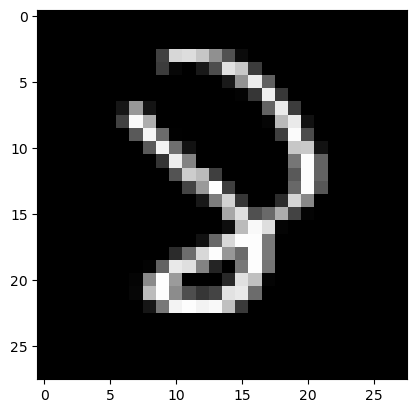

In [110]:
test_prediction(164,W1,b1,W2,b2)

In [112]:
dev_predictions = make_predictions(X_dev, W1, b1, W2, b2)
get_accuracy(dev_predictions, Y_dev)

[2 6 6 2 7 9 6 8 0 6 8 2 8 6 2 8 8 1 0 0 4 7 3 6 4 3 4 6 3 6 3 5 5 1 2 2 4
 8 2 6 5 8 0 4 9 4 2 7 4 1 0 4 0 5 8 6 4 9 2 2 8 4 6 8 2 4 1 7 3 8 1 2 2 3
 7 1 6 6 1 8 6 8 5 9 2 9 4 0 5 6 7 9 5 9 1 3 7 7 3 5 9 9 5 7 8 4 8 5 2 8 6
 4 9 2 8 0 5 2 2 9 8 8 5 8 2 0 4 1 1 3 8 0 8 5 2 4 4 4 8 1 8 1 3 7 4 7 4 1
 3 6 9 2 3 6 5 7 5 2 8 7 2 5 2 4 3 6 9 8 1 4 9 2 1 1 2 5 2 2 4 8 1 4 8 4 5
 0 5 0 5 2 8 4 3 8 9 3 8 0 1 1 5 3 2 8 2 7 7 8 7 9 0 9 9 8 2 5 2 2 1 7 9 1
 8 0 8 1 1 3 3 0 5 1 8 5 0 0 0 3 9 8 9 2 0 6 7 0 3 8 0 2 1 2 5 5 7 9 8 3 6
 2 2 8 4 0 1 1 8 0 3 0 3 8 4 8 6 3 9 9 6 5 2 2 3 7 7 9 9 1 6 5 5 1 5 7 9 2
 6 1 0 4 0 6 1 5 2 6 8 1 1 9 8 6 1 6 6 3 2 9 0 0 6 4 8 2 1 5 6 2 9 6 3 9 5
 3 6 7 2 3 0 4 6 8 1 3 2 0 6 6 5 5 4 2 0 4 2 8 5 5 0 1 2 7 5 7 7 2 0 1 7 2
 5 6 7 2 9 7 7 7 5 1 7 1 3 4 8 3 5 2 6 2 9 6 9 4 3 0 1 8 6 0 0 9 4 1 0 8 7
 0 3 8 6 0 7 2 0 7 3 1 2 8 0 6 0 1 1 5 2 9 4 2 6 4 0 2 5 1 1 6 1 3 5 9 7 8
 9 0 7 3 1 5 2 8 4 6 9 6 1 1 7 8 8 4 9 8 7 6 8 4 1 9 5 9 9 2 2 2 7 8 2 8 6
 3 6 1 9 0 4 8 7 5 7 8 4 

0.854